# Meta 2 – Análise Tempo-Frequência e Classificação

> **Projeto ATD 2025/2026** – Identificação de dígitos através de características extraídas de sinais de áudio.

---

In [2]:
import scipy.io as sio
import pandas as pd
import librosa


In [3]:
import numpy as np

# 1. Função de remover silêncio (já com a correção da janela deslizante/média móvel)
def remover_silencio(sinal, razao_limiar=0.10, tamanho_janela=100):
    limiar = razao_limiar * np.max(np.abs(sinal))
    janela = np.ones(tamanho_janela) / tamanho_janela
    sinal_suavizado = np.convolve(np.abs(sinal), janela, mode='same')
    
    i_ativos = np.where(sinal_suavizado > limiar)[0]
    
    if len(i_ativos) == 0:
        return sinal
    else:
        return sinal[i_ativos[0]:]
    
# 2. Função de normalização
def normalizar_sinal(sinal): 
    minimo = np.min(sinal)
    maximo = np.max(sinal)
    return  2 * ((sinal - minimo) / (maximo - minimo)) - 1

# 3. Função principal de pré-processamento que é chamada no ciclo
def pre_processar_sinal(sinal):
    s_silencio = remover_silencio(sinal)
    normalizado = normalizar_sinal(s_silencio)
    return normalizado

In [4]:
nome_ficheiro_mat = 'caracteristicas_extraidas_meta1.mat'
mat_dados = sio.loadmat(nome_ficheiro_mat)
dados = mat_dados['dados_meta1'][0, 0]
dicionario = {nome_coluna: dados[nome_coluna].flatten() for nome_coluna in dados.dtype.names}
df= pd.DataFrame(dicionario)
#display(df.head())

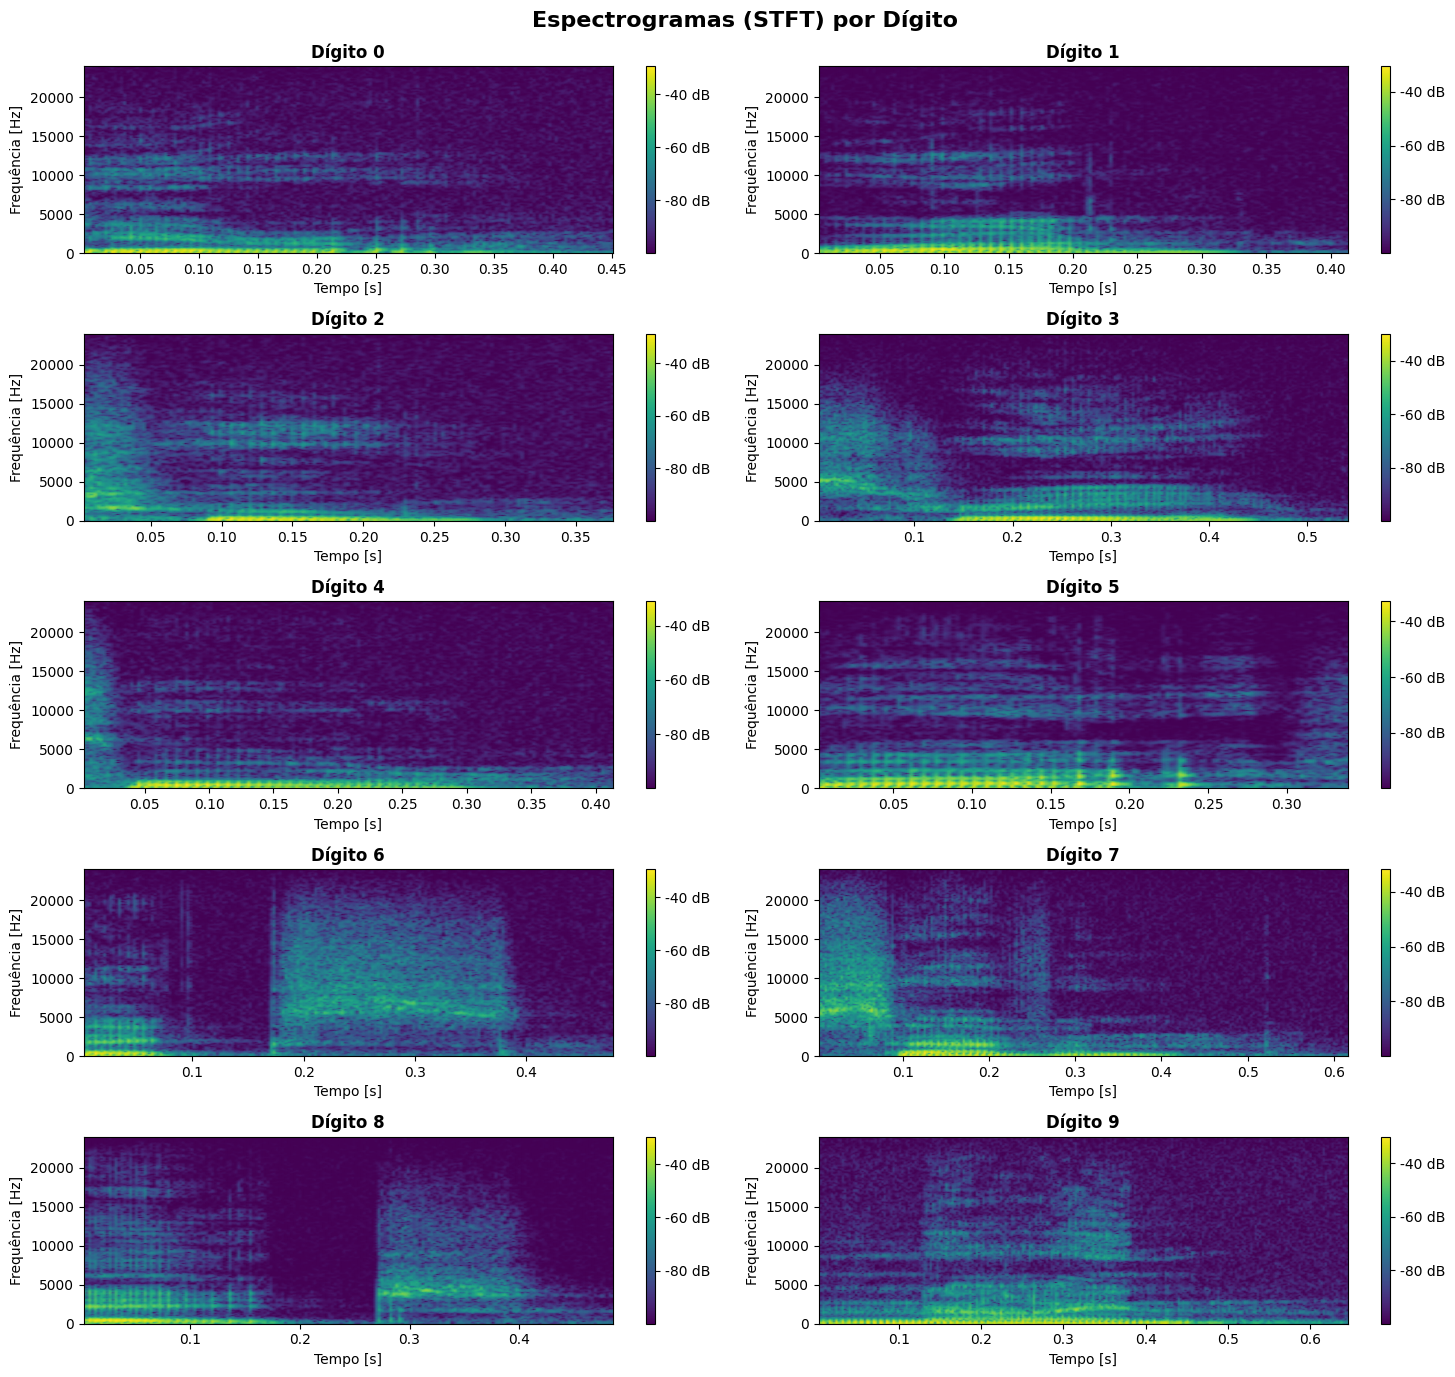

In [5]:
import os
import numpy as np
from scipy.io import wavfile
from scipy.signal import spectrogram
import matplotlib.pyplot as plt


df_stft = df[df['repeticao'] == 1].sort_values(by='digito')

# Parâmetros da STFT
tipo_janela = 'hann'

tamanho_janela = 256
sobreposicao = 128

pontos_fft = 512

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 14))
fig.suptitle('Espectrogramas (STFT) por Dígito', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i in range(10):
    if i < len(df_stft):
        linha = df_stft.iloc[i]
        digito = linha['digito']
        
        # 1. Recuperar o caminho do ficheiro (limpando possíveis formatações do .mat)
        pasta = str(linha['pasta_dados']).strip("['\"]")
        ficheiro = str(linha['ficheiro']).strip("['\"]")
        caminho_completo = os.path.join(pasta, ficheiro)
        
        # 2. Carregar o áudio original do disco
        fs, sinal_bruto = wavfile.read(caminho_completo)
        
        # 3. Pré-processar o áudio usando a sua função da Meta 1
        sinal = pre_processar_sinal(sinal_bruto)
        
        # 4. Cálculo da STFT com o sinal carregado
        f, t, Sxx = spectrogram(sinal, fs=fs, window=tipo_janela, 
                                nperseg=tamanho_janela, noverlap=sobreposicao, nfft=pontos_fft)
        
        # Converter amplitude para escala logarítmica (dB)
        Sxx_dB = 10 * np.log10(Sxx + 1e-10) 
        
        ax = axes[i]
        mesh = ax.pcolormesh(t, f, Sxx_dB, shading='gouraud', cmap='viridis')
        
        ax.set_title(f'Dígito {digito}', fontweight='bold')
        ax.set_ylabel('Frequência [Hz]')
        ax.set_xlabel('Tempo [s]')
        ax.set_ylim([0, fs/2]) 
        fig.colorbar(mesh, ax=ax, format='%+2.0f dB')

plt.tight_layout()
fig.subplots_adjust(top=0.94)
plt.show()

Testando varios parametros, entre os quais: {tipo_janela = 'hann', tamanho_janela=1024, sobreposicao=512, pontos_fft=1024} que mostrou um detalhe notável nas frequências mas falta de nitidez no tempo. {tipo_janela = 'hann', tamanho_janela=64, sobreposicao=32, pontos_fft=256} com nitidez no tempo mas falta de nitidez nas frequencias, sem ser possivel distinguir timbres e consoantes de vogais. {tipo_janela = 'hann', tamanho_janela=256, sobreposicao=128, pontos_fft=512} que mostrou ser a mais equilibrada

In [6]:
import os
import numpy as np
import pandas as pd
from scipy.io import wavfile
import librosa # Biblioteca de referência para extração avançada de áudio

# 1. Criar listas para guardar as novas features (Média e Desvio Padrão para cada uma)
mfcc_media = []
mfcc_std = []
fluxo_espetral_media = []
fluxo_espetral_std = []
centroide_stft_media = []
centroide_stft_std = []
rolloff_stft_media = []
rolloff_stft_std = []
bandwidth_stft_media = []
bandwidth_stft_std = []

print("A extrair características tempo-frequência. Isto pode demorar alguns segundos...")

# 2. Iterar sobre todos os áudios do nosso DataFrame atual (df_meta2 ou df)
for i in range(len(df)):
    linha = df.iloc[i]
    
    # Recuperar o ficheiro de áudio original (o "truque" que usámos na STFT)
    pasta = str(linha['pasta_dados']).strip("['\"]")
    ficheiro = str(linha['ficheiro']).strip("['\"]")
    caminho_completo = os.path.join(pasta, ficheiro)
    
    # Ler e pré-processar (certifique-se de que a função pre_processar_sinal está corrida)
    fs, sinal_bruto = wavfile.read(caminho_completo)
    sinal = pre_processar_sinal(sinal_bruto)
    
    # A librosa trabalha melhor com sinais no formato float32
    sinal = sinal.astype(np.float32)
    
    # --- EXTRAÇÃO DAS 5 CARACTERÍSTICAS (Tempo-Frequência) ---
    
    # A) MFCCs (Extraímos os primeiros 13 coeficientes de cada janela)
    mfccs = librosa.feature.mfcc(y=sinal, sr=fs, n_mfcc=13)
    mfcc_media.append(np.mean(mfccs))
    mfcc_std.append(np.std(mfccs))
    
    # B) Fluxo Espetral (A librosa usa 'onset_strength' para medir a variação de energia entre frames)
    fluxo = librosa.onset.onset_strength(y=sinal, sr=fs)
    fluxo_espetral_media.append(np.mean(fluxo))
    fluxo_espetral_std.append(np.std(fluxo))
    
    # C) Contorno do Centroide Espetral
    centroide = librosa.feature.spectral_centroid(y=sinal, sr=fs)
    centroide_stft_media.append(np.mean(centroide))
    centroide_stft_std.append(np.std(centroide))
    
    # D) Contorno da Frequência de Corte (Roll-off a 85%)
    rolloff = librosa.feature.spectral_rolloff(y=sinal, sr=fs, roll_percent=0.85)
    rolloff_stft_media.append(np.mean(rolloff))
    rolloff_stft_std.append(np.std(rolloff))
    
    # E) Contorno da Largura de Banda Espetral
    bandwidth = librosa.feature.spectral_bandwidth(y=sinal, sr=fs)
    bandwidth_stft_media.append(np.mean(bandwidth))
    bandwidth_stft_std.append(np.std(bandwidth))

# 3. Atualizar o DataFrame de forma robusta com as 10 novas colunas
df['mfcc_media'] = mfcc_media
df['mfcc_std'] = mfcc_std
df['fluxo_espetral_media'] = fluxo_espetral_media
df['fluxo_espetral_std'] = fluxo_espetral_std
df['centroide_stft_media'] = centroide_stft_media
df['centroide_stft_std'] = centroide_stft_std
df['rolloff_stft_media'] = rolloff_stft_media
df['rolloff_stft_std'] = rolloff_stft_std
df['bandwidth_stft_media'] = bandwidth_stft_media
df['bandwidth_stft_std'] = bandwidth_stft_std

print("Estrutura de dados atualizada com sucesso com as novas features tempo-frequência!")
# Visualizar o resultado para comprovar ao Júri que os dados estão prontos
display(df.head())

A extrair características tempo-frequência. Isto pode demorar alguns segundos...


c:\Users\tdami\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Estrutura de dados atualizada com sucesso com as novas features tempo-frequência!


,pasta_dados,ficheiro,participante,digito,repeticao,taxa_amostragem,energia_total,zcr,rms,desvio_padrao,...,mfcc_media,mfcc_std,fluxo_espetral_media,fluxo_espetral_std,centroide_stft_media,centroide_stft_std,rolloff_stft_media,rolloff_stft_std,bandwidth_stft_media,bandwidth_stft_std
0,[01],[0_01_0.wav],[01],0,0,48000,2007.277011,229.5,0.243037,0.228646,...,1.729635,87.183655,0.780814,0.415314,1409.125887,331.207290,1847.812500,1067.323884,3400.730162,633.476352
1,[01],[0_01_1.wav],[01],0,1,48000,1857.928920,164.5,0.233821,0.213321,...,3.504125,84.695152,0.942458,0.714497,1345.065660,291.874507,1686.409884,898.492923,3469.001899,500.832476
2,[01],[0_01_2.wav],[01],0,2,48000,2694.037104,868.5,0.281560,0.249726,...,2.040204,79.112747,0.954984,0.557285,2277.181103,2170.001293,3279.229526,3952.606021,3573.658582,712.595098
3,[01],[0_01_3.wav],[01],0,3,48000,1204.655418,359.5,0.188278,0.183443,...,-0.116890,88.496582,1.026728,0.789661,1558.853669,428.470939,2386.117788,1233.996818,3382.648624,793.636771
4,[01],[0_01_4.wav],[01],0,4,48000,791.993948,283.5,0.152662,0.150728,...,-2.368127,96.388412,0.847344,0.690177,1436.316457,473.558915,2080.729167,1130.926651,2897.431279,802.404181


In [12]:
import os
import numpy as np
import pandas as pd
from scipy.io import wavfile
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. EXTRAÇÃO DAS CARACTERÍSTICAS EM 7 JANELAS TEMPORAIS
# =====================================================================
print("A fatiar (em 7 janelas) e a extrair características. Aguarde...")

n_fatias = 7

# Dicionário dinâmico para guardar as listas
features_fatiadas = {}
nomes_features_base = ['mfcc', 'fluxo', 'centroide', 'rolloff', 'bandwidth']

for base in nomes_features_base:
    for j in range(1, n_fatias + 1):
        features_fatiadas[f"{base}_w{j}"] = [] # w = window (janela)

for i in range(len(df)):
    linha = df.iloc[i]
    
    # Recuperar e ler o áudio
    pasta = str(linha['pasta_dados']).strip("['\"]")
    ficheiro = str(linha['ficheiro']).strip("['\"]")
    caminho_completo = os.path.join(pasta, ficheiro)
    
    fs, sinal_bruto = wavfile.read(caminho_completo)
    sinal = pre_processar_sinal(sinal_bruto).astype(np.float32)
    
    # Extrair vetores ao longo do tempo usando librosa
    mfccs = librosa.feature.mfcc(y=sinal, sr=fs, n_mfcc=13)
    fluxo = librosa.onset.onset_strength(y=sinal, sr=fs)
    centroide = librosa.feature.spectral_centroid(y=sinal, sr=fs)[0]
    rolloff = librosa.feature.spectral_rolloff(y=sinal, sr=fs, roll_percent=0.85)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=sinal, sr=fs)[0]
    
    # Fatiar os arrays em 7 pedaços (o np.array_split lida com a divisão de forma ótima)
    # Nota para os MFCCs: O array tem a forma (13, n_frames). O split é feito na dimensão dos frames (axis=1).
    fatias_mfcc = np.array_split(mfccs, n_fatias, axis=1)
    fatias_fluxo = np.array_split(fluxo, n_fatias)
    fatias_centroide = np.array_split(centroide, n_fatias)
    fatias_rolloff = np.array_split(rolloff, n_fatias)
    fatias_bandwidth = np.array_split(bandwidth, n_fatias)
    
    # Preencher o dicionário com as médias de cada uma das 7 fatias
    for j in range(n_fatias):
        features_fatiadas[f"mfcc_w{j+1}"].append(np.mean(fatias_mfcc[j]))
        features_fatiadas[f"fluxo_w{j+1}"].append(np.mean(fatias_fluxo[j]))
        features_fatiadas[f"centroide_w{j+1}"].append(np.mean(fatias_centroide[j]))
        features_fatiadas[f"rolloff_w{j+1}"].append(np.mean(fatias_rolloff[j]))
        features_fatiadas[f"bandwidth_w{j+1}"].append(np.mean(fatias_bandwidth[j]))

# Atualizar o DataFrame
for nome, valores in features_fatiadas.items():
    df[nome] = valores

print("Estrutura atualizada com 35 novas features (5 características x 7 janelas)!")

A fatiar (em 7 janelas) e a extrair características. Aguarde...
Estrutura atualizada com 35 novas features (5 características x 7 janelas)!


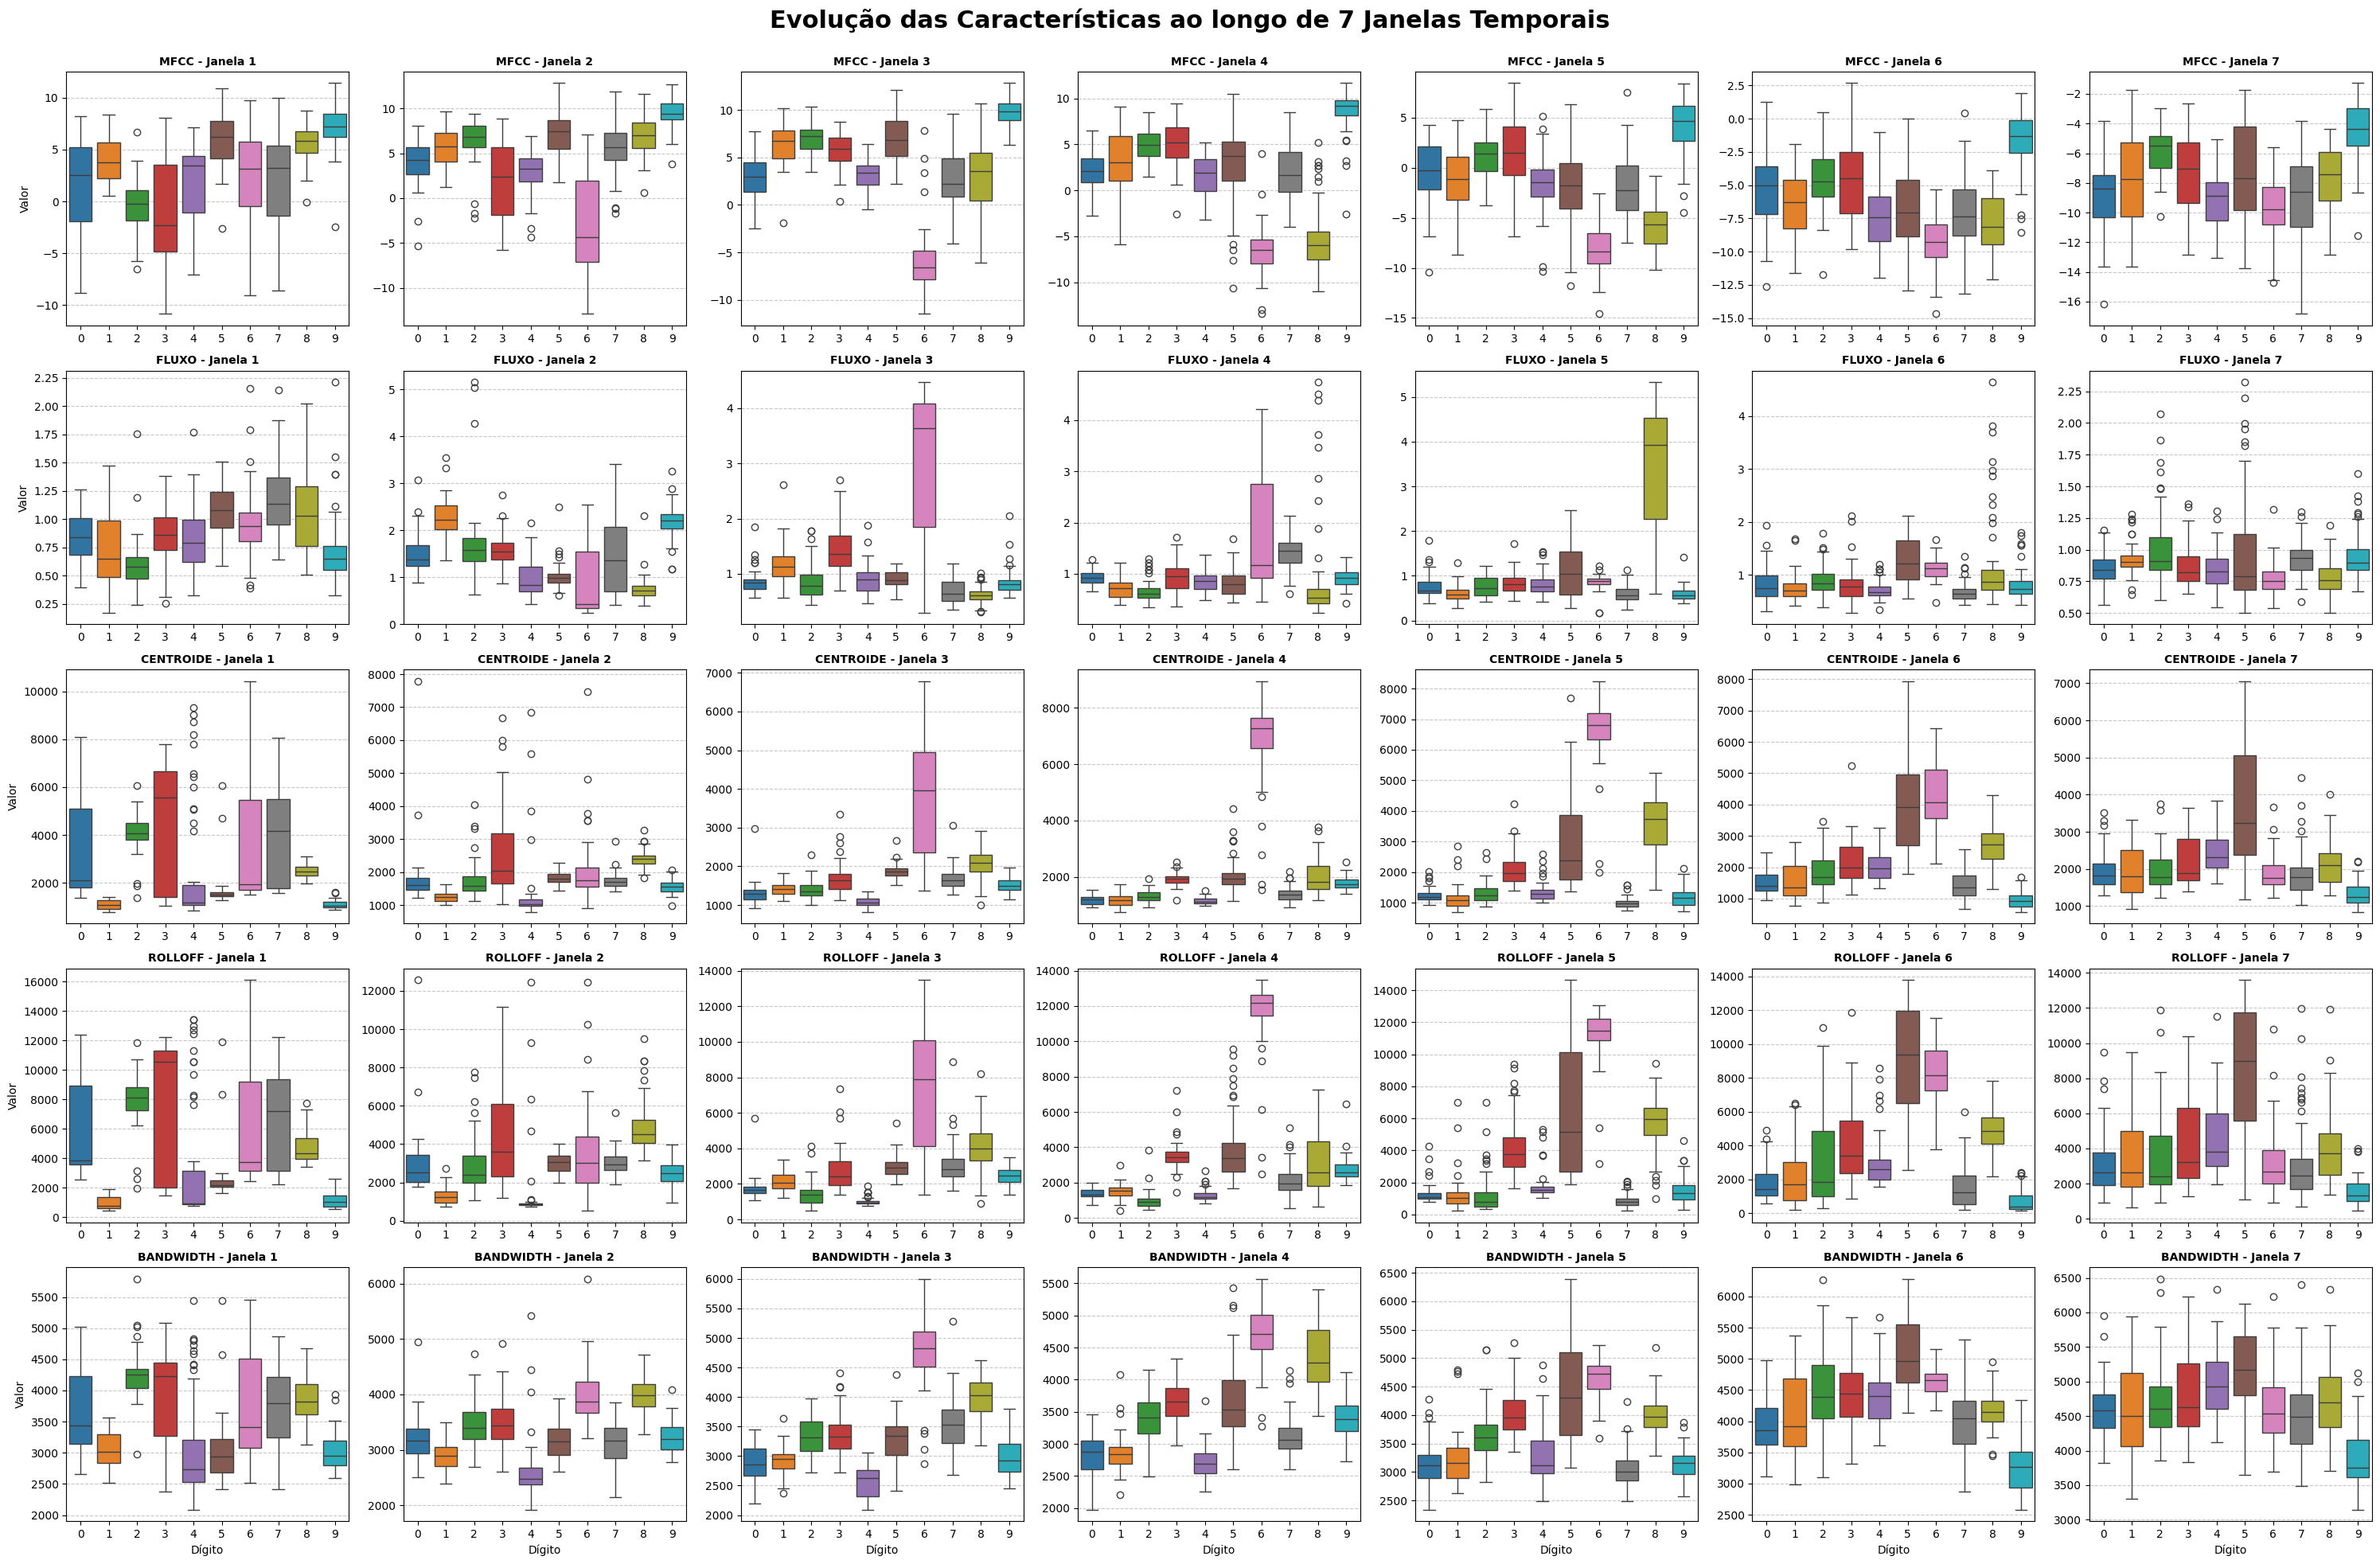

In [13]:
# =====================================================================
# 2. REPRESENTAÇÃO GRÁFICA (BOXPLOTS)
# =====================================================================

fig, axes = plt.subplots(nrows=5, ncols=7, figsize=(30, 20))
fig.suptitle('Evolução das Características ao longo de 7 Janelas Temporais', fontsize=22, fontweight='bold')
paleta = sns.color_palette("tab10", 10)

for lin, base in enumerate(nomes_features_base):
    for col in range(n_fatias):
        nome_feature = f"{base}_w{col+1}"
        ax = axes[lin, col]
        
        sns.boxplot(x='digito', y=nome_feature, data=df, ax=ax, hue='digito', palette=paleta, legend=False)
        ax.set_title(f"{base.upper()} - Janela {col+1}", fontweight='bold', fontsize=10)
        
        # Limpar rótulos para não sobrecarregar o gráfico gigante
        if lin == 4:
            ax.set_xlabel('Dígito')
        else:
            ax.set_xlabel('')
            
        if col == 0:
            ax.set_ylabel('Valor')
        else:
            ax.set_ylabel('')
            
        ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
fig.subplots_adjust(top=0.94)
plt.show()